In [1]:
# Plot time series of OSDMA8 globally

In [2]:
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.utils import autosize_figure
from utils.utils import land_filter

In [3]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"
SCENARIOS = ["ARISE", "SSP245"]


# === Main loop ===
arise_land = xr.open_dataarray(f"{OSDMA8_DIR}OSDMA8_BC_globalmean_CESM2_ARISE_2035-2068.nc")
ssp245_land = xr.open_dataarray(f"{OSDMA8_DIR}OSDMA8_BC_globalmean_CESM2_SSP245_2020-2068.nc")

In [4]:
years = np.arange(2035, 2069)  # Creates array [2035, 2036, ..., 2068]
arise_land = arise_land.assign_coords(time=years)

In [5]:
years = np.arange(2020, 2069)  # Creates array [2020, 2021, ..., 2068]
ssp245_land = ssp245_land.assign_coords(time=years)

Text(0.5, 1.0, 'Difference in Global OSDMA8')

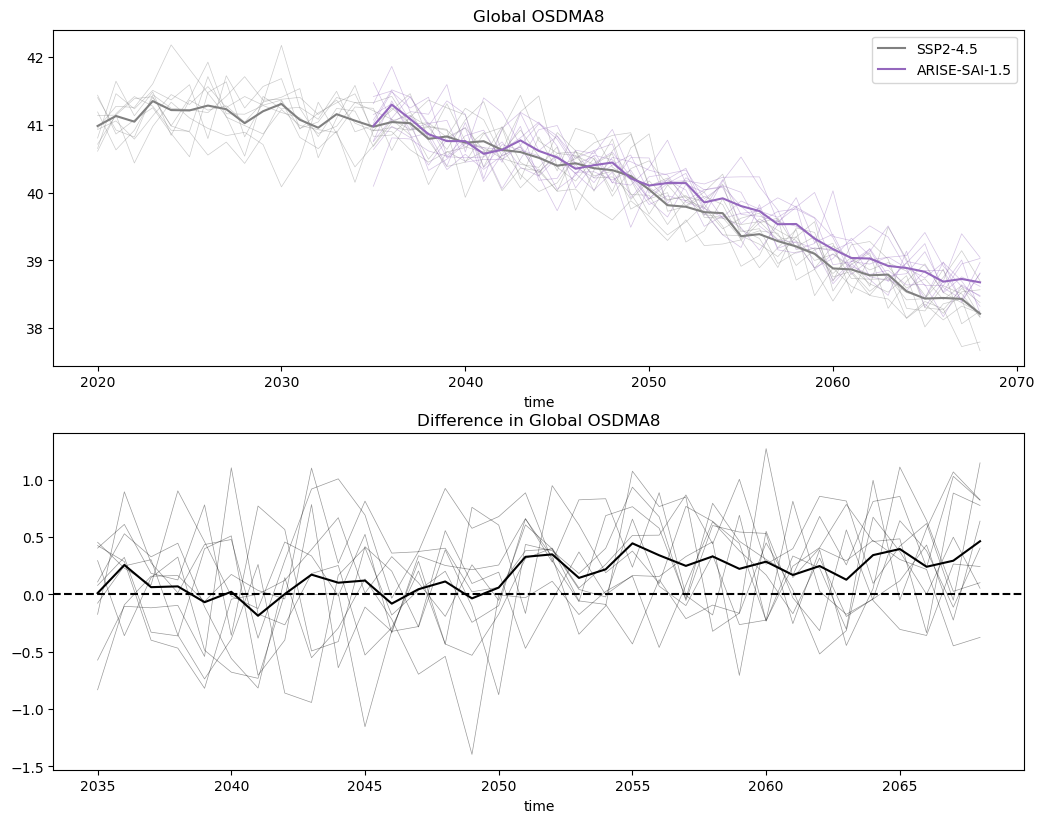

In [6]:
fig = plt.figure(figsize=autosize_figure(2, 1, xscale_factor=1.5))
gs = GridSpec(2, 1) # rows, columns

ax1 = fig.add_subplot(gs[0, 0])
for ens_num in range(1, 11):
    ssp245_land.sel(ensemble=ens_num).plot(color='grey', alpha=0.4, linewidth=0.5)
    arise_land.sel(ensemble=ens_num).plot(color='tab:purple', alpha=0.4, linewidth=0.5)
ssp245_land.mean("ensemble").plot(color='grey', label="SSP2-4.5")
arise_land.mean("ensemble").plot(color='tab:purple', label="ARISE-SAI-1.5")
plt.title("Global OSDMA8")
plt.legend()

ax2 = fig.add_subplot(gs[1, 0])
ssp245_time = ssp245_land.sel(time=slice(2035, 2069))
for ens_num in range(1, 11):
    (arise_land - ssp245_time).sel(ensemble=ens_num).plot(color='k', alpha=0.4, linewidth=0.5)
(arise_land - ssp245_time).mean("ensemble").plot(color='k')
plt.axhline(0, color='k', linestyle='--')
plt.title("Difference in Global OSDMA8")